# Projet de Machine Learning
## Gym Members Exercise Dataset

### EHRHART Elsa, SLISSE Paul, STAUB Guillaume, HOSSEINI Arman

### I.Exploration et nettoyage du dataset

In [12]:
path <- "spotify_songs.csv"
song <- read.csv(path, header = TRUE)
# Premières lignes du jeu de données
head(song)
# Vérification du contenu
summary(song)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxury Remix,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury Remix],2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194754
2,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162600
3,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176616
4,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169093
5,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189052
6,7fvUMiyapMsRRxr07cU8Ef,Beautiful People (feat. Khalid) - Jack Wins Remix,Ed Sheeran,67,2yiy9cd2QktrNvWC2EUi0k,Beautiful People (feat. Khalid) [Jack Wins Remix],2019-07-11,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,8,-5.385,1,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163049


   track_id          track_name        track_artist       track_popularity
 Length:32833       Length:32833       Length:32833       Min.   :  0.00  
 Class :character   Class :character   Class :character   1st Qu.: 24.00  
 Mode  :character   Mode  :character   Mode  :character   Median : 45.00  
                                                          Mean   : 42.48  
                                                          3rd Qu.: 62.00  
                                                          Max.   :100.00  
 track_album_id     track_album_name   track_album_release_date
 Length:32833       Length:32833       Length:32833            
 Class :character   Class :character   Class :character        
 Mode  :character   Mode  :character   Mode  :character        
                                                               
                                                               
                                                               
 playlist_name      playlis

>Premièrement, nous allons supprimer les variables inutiles à l'analyse comme le track_id (un identifiant différent par musique) qui ne sera d'aucune utilité pour notre analyse car l'information est déjà contenue dans la variable track_name que nous n'utiliserons que pour labelliser.
De même, on va supprimer track_album_id,playlist_id.

In [13]:
song<-subset(song,select=-track_id)
song<-subset(song,select=-track_album_id)
song<-subset(song,select=-playlist_id)
song<-subset(song, select=-track_name)


colnames(song)[which(colnames(song)=="duration_ms")]<-"duration_s"
song[,"duration_s"]<-song[,"duration_s"]/1000
head(song)

,track_artist,track_popularity,track_album_name,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Ed Sheeran,66,I Don't Care (with Justin Bieber) [Loud Luxury Remix],2019-06-14,Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194.754
2,Maroon 5,67,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162.600
3,Zara Larsson,70,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176.616
4,The Chainsmokers,60,Call You Mine - The Remixes,2019-07-19,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169.093
5,Lewis Capaldi,69,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189.052
6,Ed Sheeran,67,Beautiful People (feat. Khalid) [Jack Wins Remix],2019-07-11,Pop Remix,pop,dance pop,0.675,0.919,8,-5.385,1,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163.049


>On modifie certaines variables qualitatives qui nous serons utiles pour l'analyse en facteurs. D'autres comme track_name sont laissées telles quelles et seront utilisées pour la visualisation (labellisation).

In [21]:
song[,"playlist_genre"]<-as.factor(song[,"playlist_genre"])
song[,"playlist_subgenre"]<-as.factor(song[,"playlist_subgenre"])
song[,"mode"]<-as.factor(song[,"mode"])
song[,"track_artist"]<-as.factor(song[,"track_artist"])
song[,"track_album_name"]<-as.factor(song[,"track_album_name"])
song[,"playlist_name"]<-as.factor(song[,"playlist_name"])

In [22]:
library(lubridate)
song <- data.frame(song)
#summary(song)
song$month <- format(as.Date(song$track_album_release_date, "%Y-%m-%d"), "%m")
#summary(song)
song$year <- format(as.Date(song$track_album_release_date, "%Y-%m-%d"), "%Y")
song<-subset(song, select=-track_album_release_date)

ERROR: Error in `$<-.data.frame`(`*tmp*`, month, value = character(0)): le tableau de remplacement a 0 lignes, le tableau remplacé en a 32833


In [ ]:
song$month<-as.factor(song$month)
song$year<-as.factor(song$year)

# Apperçu sur le dataset

In [ ]:
summary(song)

In [18]:
library(ggplot2)
histo_genre <- ggplot(song,aes(x=playlist_genre))+
  geom_histogram(stat="count")+
  labs(title = "Distribution des genres des musiques")

histo_year <- ggplot(song,aes(x=year))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des années de sortie des musiques")+
    scale_x_discrete(breaks = levels(factor(song$year))[seq(1, length(levels(factor(song$year))), by = 10)])

histo_month <- ggplot(song,aes(x=month))+
    geom_histogram(stat="count",fill='blue')+
    labs(title = "Distribution des mois de sortie des musiques")

histo_popularity <- ggplot(song,aes(x=track_popularity))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des popularités des musiques")

histo_danceability <- ggplot(song,aes(x=danceability))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la danceabilité des musiques")

histo_energy <- ggplot(song,aes(x=energy))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'energie des musiques")

histo_key <- ggplot(song,aes(x=key))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de la clé des musiques")

histo_loudness <- ggplot(song,aes(x=loudness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la force sonore des musiques")

histo_mode  <- ggplot(song,aes(x=mode))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de du mode des musiques")

histo_speechiness <- ggplot(song,aes(x=speechiness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la vocabilité des musiques")

histo_instrumentalness <- ggplot(song,aes(x=instrumentalness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'intrumentabilité des musiques")

histo_liveness <- ggplot(song,aes(x=liveness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la liveness des musiques")

histo_valence <- ggplot(song,aes(x=valence))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la valence des musiques")

histo_tempo <- ggplot(song,aes(x=tempo))+
    geom_histogram(bins=50)+
    labs(title = "Distribution du tempo des musiques")

histo_duration_s <- ggplot(song,aes(x=duration_s))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la durée des musiques")







Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count", fill = "blue"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(bins = 50, stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(bins = 50, stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"


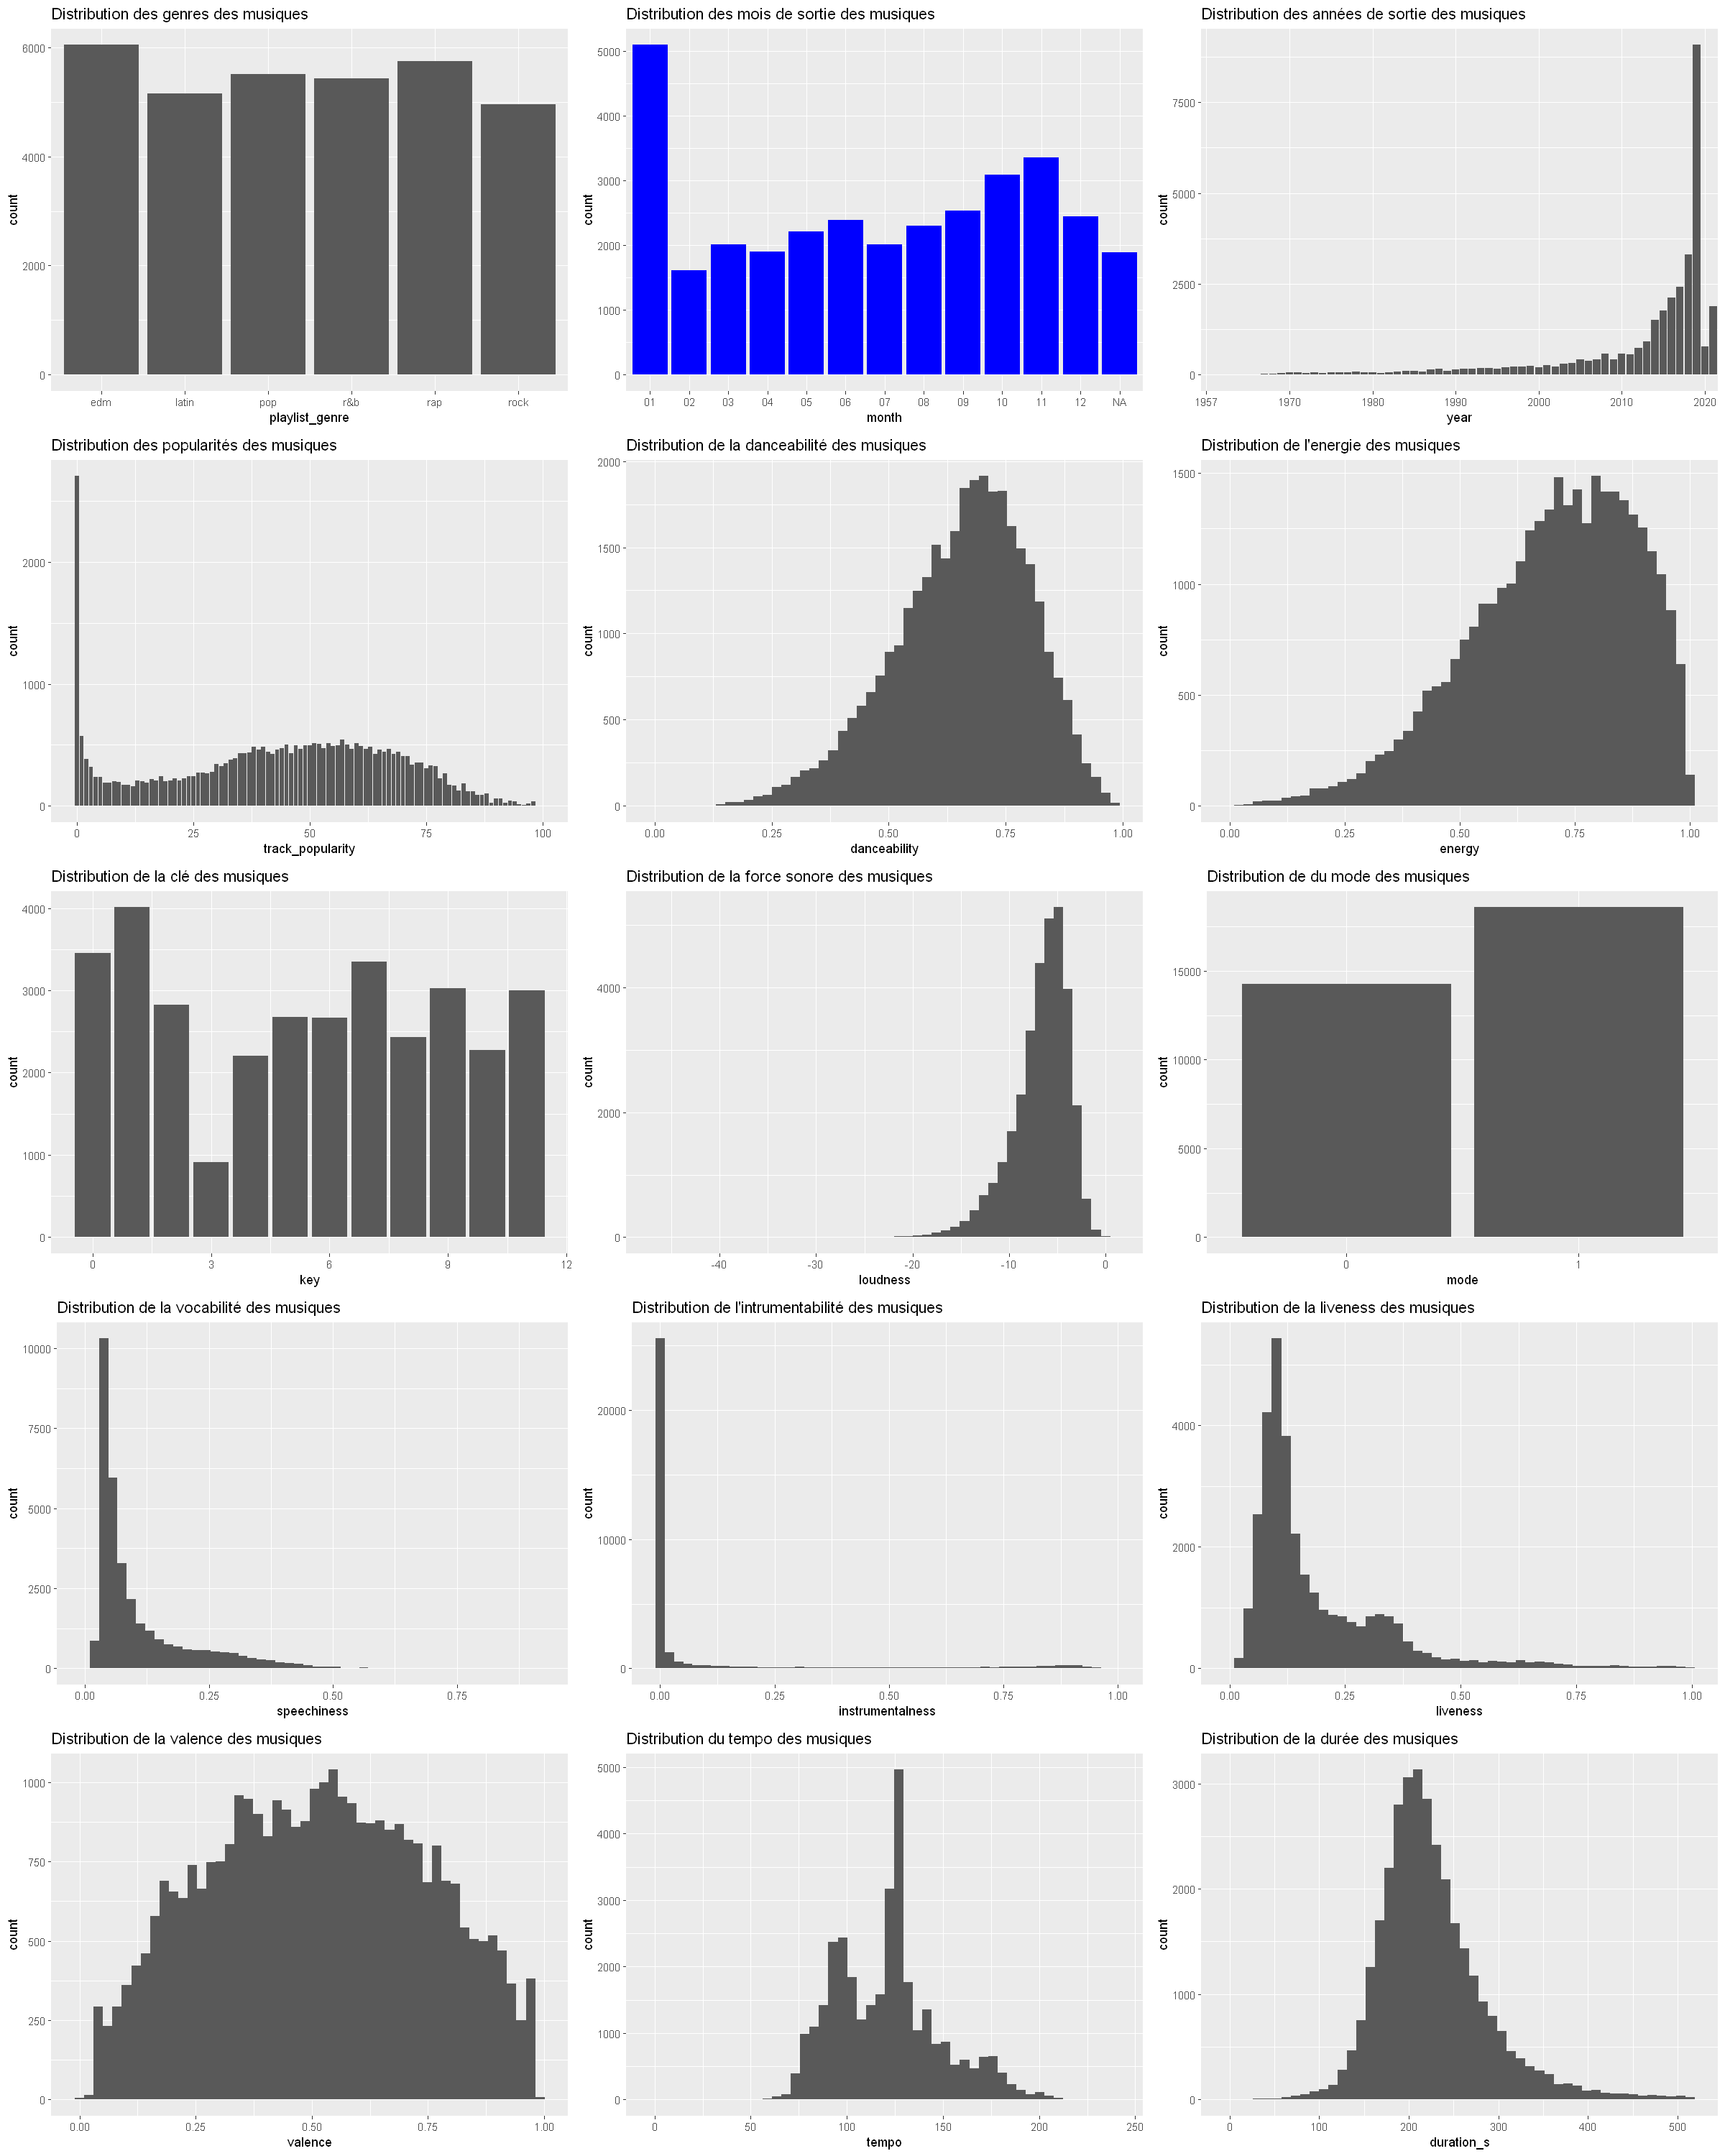

In [19]:
library("gridExtra")
options(repr.plot.width=20, repr.plot.height=25)
grid.arrange(histo_genre,histo_month,histo_year, histo_popularity,histo_danceability,histo_energy,histo_key,histo_loudness,histo_mode,histo_speechiness, histo_instrumentalness, histo_liveness,histo_valence,histo_tempo,histo_duration_s, ncol=3)

In [20]:
histo_genre <- ggplot(song,aes(x=playlist_genre,fill="mode"))+
  geom_histogram(stat="count")+
  labs(title = "Distribution des genres des musiques")

histo_year <- ggplot(song,aes(x=year,fill="genre"))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des années de sortie des musiques")+
    scale_x_discrete(breaks = levels(factor(song$year))[seq(1, length(levels(factor(song$year))), by = 10)])

histo_month <- ggplot(song,aes(x=month,fill="genre"))+
    geom_histogram(stat="count",fill='blue')+
    labs(title = "Distribution des mois de sortie des musiques")

histo_popularity <- ggplot(song,aes(x=track_popularity,fill="genre"))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des popularités des musiques")

histo_danceability <- ggplot(song,aes(x=danceability,fill="genre"))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la danceabilité des musiques")

histo_energy <- ggplot(song,aes(x=energy,fill="genre"))+
geom_histogram(bins=50)+
    labs(title = "Distribution de l'energie des musiques")

histo_key <- ggplot(song,aes(x=key,fill="genre"))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de la clé des musiques")

histo_loudness <- ggplot(song,aes(x=loudness,fill="genre"))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la force sonore des musiques")

histo_mode  <- ggplot(song,aes(x=mode,fill="genre"))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de du mode des musiques")

histo_speechiness <- ggplot(song,aes(x=speechiness,fill="genre"))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la vocabilité des musiques")

histo_instrumentalness <- ggplot(song,aes(x=instrumentalness,fill="genre"))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'intrumentabilité des musiques")

histo_liveness <- ggplot(song,aes(x=liveness,fill="genre"))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la liveness des musiques")

histo_valence <- ggplot(song,aes(x=valence,fill="genre"))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la valence des musiques")

histo_tempo <- ggplot(song,aes(x=tempo,fill="genre"))+
    geom_histogram(bins=50)+
    labs(title = "Distribution du tempo des musiques")

histo_duration_s <- ggplot(song,aes(x=duration_s,fill="genre"))+
    geom_histogram(bins=50)+
labs(title = "Distribution de la durée des musiques")

Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count", fill = "blue"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(bins = 50, stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"
Warning message in geom_histogram(bins = 50, stat = "count"):
"Ignoring unknown parameters: `binwidth`, `bins`, and `pad`"


In [ ]:
library("FactomineR")

PCA(